# Système de Recommandation de Spécialités pour Étudiants - Promotion 2022

## Objectif
Ce notebook implémente un système de recommandation qui assigne chaque étudiant de la **promotion 2022** à l'une des 4 spécialités en fonction de leurs notes dans différents modules.

### Les 4 spécialités :
- **SIQ** (Systèmes & Réseaux) → RES1, SYS1, SYS2, RES2, SEC
- **SID** (Mathématiques & Algorithmes / Architecture) → ANUM, RO, THP, ARCH  
- **SIT** (Management & Projets IT) → ORG, CPROJ, PROJ, MCSI
- **SIL** (Génie Logiciel) → IGL, BDD

### Méthodologie :
1. **Filtrage** : Sélection des étudiants de la promotion 2022 uniquement
2. **Normalisation** des notes (z-score)
3. **Calcul** des scores moyens par spécialité
4. **Normalisation** des scores pour créer un profil
5. **Recommandation** avec explication

### 🎓 Scope de l'analyse :
- **Population cible** : Promotion 2022
- **Critères de filtrage** : Matricules commençant par "22/" ou colonne promotion = 2022
- **Objectif** : Recommandations spécifiques à cette cohorte d'étudiants

## 1. Importation des bibliothèques

In [42]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings

# Configuration pour un affichage optimal
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configuration de l'affichage des DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


## 2. Chargement et exploration des données

In [43]:
# Définition des modules par spécialité
specialites = {
    'SIQ': ['RES1', 'SYS1', 'SYS2', 'RES2', 'SEC'],        # Systèmes & Réseaux
    'SID': ['ANUM', 'RO', 'THP', 'ARCH'],                   # Mathématiques & Algorithmes / Architecture
    'SIT': ['ORG', 'CPROJ', 'PROJ', 'MCSI'],                # Management & Projets IT
    'SIL': ['IGL', 'BDD']                                    # Génie Logiciel
}

# Affichage des spécialités et leurs modules
print("📚 SPÉCIALITÉS ET MODULES ASSOCIÉS :")
print("=" * 50)
for spec, modules in specialites.items():
    print(f"{spec}: {', '.join(modules)}")

# Tous les modules nécessaires
tous_modules = []
for modules in specialites.values():
    tous_modules.extend(modules)

print(f"\n📊 Total de {len(tous_modules)} modules à analyser: {tous_modules}")

📚 SPÉCIALITÉS ET MODULES ASSOCIÉS :
SIQ: RES1, SYS1, SYS2, RES2, SEC
SID: ANUM, RO, THP, ARCH
SIT: ORG, CPROJ, PROJ, MCSI
SIL: IGL, BDD

📊 Total de 15 modules à analyser: ['RES1', 'SYS1', 'SYS2', 'RES2', 'SEC', 'ANUM', 'RO', 'THP', 'ARCH', 'ORG', 'CPROJ', 'PROJ', 'MCSI', 'IGL', 'BDD']


In [44]:
# Chargement des données des étudiants - PROMOTION 2022 UNIQUEMENT
try:
    # Essayer de charger le fichier avec progression complète
    df_complet = pd.read_csv('1822_1cs.csv')
    print(f"✅ Données complètes chargées: {len(df_complet)} étudiants trouvés")
    source_data = "1822_1cs.csv"
    
    # Examiner les colonnes disponibles pour identifier la promotion
    print(f"\n🔍 Colonnes disponibles: {list(df_complet.columns)}")
    
    # Filtrer pour la promotion 2022
    # Vérifier les différentes façons dont la promotion peut être encodée
    promotion_columns = [col for col in df_complet.columns if 'promo' in col.lower()]
    print(f"📅 Colonnes de promotion trouvées: {promotion_columns}")
    
    # Examiner les valeurs uniques dans les colonnes de promotion
    for col in promotion_columns:
        valeurs_uniques = df_complet[col].dropna().unique()
        print(f"   {col}: {sorted(valeurs_uniques)}")
    
    # Filtrer pour 2022 en utilisant le matricule (format XX/YYYY suggère l'année)
    # Les matricules commençant par 22/ sont de la promotion 2022
    df_2022_matricule = df_complet[df_complet['Matricule'].str.startswith('22/', na=False)]
    print(f"📊 Étudiants avec matricule 22/: {len(df_2022_matricule)}")
    
    # Si on trouve des colonnes de promotion, filtrer aussi par là
    if promotion_columns:
        # Utiliser la première colonne de promotion trouvée
        col_promo = promotion_columns[0]
        df_2022_promo = df_complet[df_complet[col_promo] == 2022]
        print(f"📊 Étudiants avec promotion 2022 dans {col_promo}: {len(df_2022_promo)}")
        
        # Combiner les deux critères si possible
        if len(df_2022_promo) > 0:
            df = df_2022_promo.copy()
            filtre_utilise = f"Colonne {col_promo} = 2022"
        else:
            df = df_2022_matricule.copy()
            filtre_utilise = "Matricule commençant par 22/"
    else:
        df = df_2022_matricule.copy()
        filtre_utilise = "Matricule commençant par 22/"
    
    if len(df) == 0:
        print("⚠️  Aucun étudiant de la promotion 2022 trouvé, utilisation de toutes les données")
        df = df_complet.copy()
        filtre_utilise = "Toutes les promotions (aucun filtre 2022 applicable)"
    
    print(f"\n🎯 FILTRE APPLIQUÉ: {filtre_utilise}")
    print(f"✅ Données de la promotion 2022: {len(df)} étudiants sélectionnés")
    
except FileNotFoundError:
    print("❌ Aucun fichier de données trouvé. Création d'un dataset d'exemple...")
    # Créer un dataset d'exemple avec des matricules 2022
    np.random.seed(42)
    n_students = 50
    
    data = {'Matricule': [f"22/{i:04d}" for i in range(1, n_students + 1)]}
    for module in tous_modules:
        data[module] = np.random.normal(12, 3, n_students).clip(0, 20)
    
    df = pd.DataFrame(data)
    source_data = "Dataset d'exemple généré (promotion 2022)"
    filtre_utilise = "Dataset d'exemple - promotion 2022"

print(f"\n📋 Source des données: {source_data}")
print(f"📏 Dimensions finales: {df.shape}")
print(f"🎓 Promotion ciblée: 2022")

# Vérification de la présence des modules requis
modules_manquants = [module for module in tous_modules if module not in df.columns]
if modules_manquants:
    print(f"⚠️  Modules manquants: {modules_manquants}")
else:
    print("✅ Tous les modules requis sont présents")

# Aperçu des données de la promotion 2022
print("\n📊 APERÇU DES DONNÉES (PROMOTION 2022):")
print("=" * 60)
colonnes_a_afficher = ['Matricule'] + tous_modules
if all(col in df.columns for col in colonnes_a_afficher):
    print(df[colonnes_a_afficher].head(10))
else:
    print(df[['Matricule'] + [col for col in tous_modules if col in df.columns]].head(10))

# Afficher quelques statistiques sur la promotion 2022
if 'Matricule' in df.columns:
    matricules_2022 = df[df['Matricule'].str.startswith('22/', na=False)]
    print(f"\n📈 Statistiques promotion 2022:")
    print(f"   • Total étudiants: {len(df)}")
    print(f"   • Matricules 22/: {len(matricules_2022)}")
    if len(matricules_2022) > 0:
        print(f"   • Premier matricule: {matricules_2022['Matricule'].iloc[0]}")
        print(f"   • Dernier matricule: {matricules_2022['Matricule'].iloc[-1]}")

✅ Données complètes chargées: 984 étudiants trouvés

🔍 Colonnes disponibles: ['Matricule', 'SYS1', 'RES1', 'ANUM', 'RO', 'ORG', 'LANG1', 'IGL', 'THP', 'Rang S1', 'Moy S1', 'MCSI', 'BDD', 'SEC', 'CPROJ', 'PROJ', 'LANG2', 'ARCH', 'SYS2', 'RES2', 'Rang S2', 'Moy S2', 'Rang', 'Moy Rachat', 'Affectation', 'Promo']
📅 Colonnes de promotion trouvées: ['Promo']
   Promo: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
📊 Étudiants avec matricule 22/: 176
📊 Étudiants avec promotion 2022 dans Promo: 217

🎯 FILTRE APPLIQUÉ: Colonne Promo = 2022
✅ Données de la promotion 2022: 217 étudiants sélectionnés

📋 Source des données: 1822_1cs.csv
📏 Dimensions finales: (217, 26)
🎓 Promotion ciblée: 2022
✅ Tous les modules requis sont présents

📊 APERÇU DES DONNÉES (PROMOTION 2022):
  Matricule   RES1   SYS1   SYS2   RES2    SEC   ANUM     RO    THP   ARCH    ORG  CPROJ   PROJ   MCSI    IGL    BDD
0   22/0040  15.80  16.60  16.12  16.76  19.67  16.13  14.47  18.25  16.49  14.7

In [45]:
# Analyse des données manquantes et statistiques descriptives - PROMOTION 2022
print("📈 ANALYSE DES DONNÉES (PROMOTION 2022):")
print("=" * 60)

# Vérifier les valeurs manquantes pour les modules requis
modules_disponibles = [col for col in tous_modules if col in df.columns]
if modules_disponibles:
    df_modules = df[modules_disponibles]
    
    print("🔍 Valeurs manquantes par module (Promotion 2022):")
    valeurs_manquantes = df_modules.isnull().sum()
    for module in modules_disponibles:
        if valeurs_manquantes[module] > 0:
            pourcentage = (valeurs_manquantes[module] / len(df)) * 100
            print(f"  {module}: {valeurs_manquantes[module]} ({pourcentage:.1f}%)")
    
    if valeurs_manquantes.sum() == 0:
        print("  ✅ Aucune valeur manquante détectée")
    
    print(f"\n📊 Statistiques descriptives des modules (Promotion 2022 - {len(df)} étudiants):")
    print(df_modules.describe().round(2))
    
    # Nettoyer les données en supprimant les lignes avec des valeurs manquantes
    df_clean = df.dropna(subset=modules_disponibles)
    print(f"\n🧹 Données nettoyées (Promotion 2022): {len(df_clean)} étudiants conservés")
    print(f"   (suppression de {len(df) - len(df_clean)} lignes avec valeurs manquantes)")
    
    # Mettre à jour le DataFrame principal
    df = df_clean.copy()
    
    # Statistiques spécifiques à la promotion 2022
    if len(df) > 0:
        print(f"\n🎯 RÉSUMÉ PROMOTION 2022:")
        print(f"   • Effectif final: {len(df)} étudiants")
        print(f"   • Modules analysés: {len(modules_disponibles)}")
        print(f"   • Taux de complétude: {len(df_clean)/len(df)*100:.1f}%")
        
        # Afficher les moyennes générales par module pour la promotion 2022
        print(f"\n📊 Moyennes par module (Promotion 2022):")
        moyennes_modules = df_modules.mean().sort_values(ascending=False)
        for module, moyenne in moyennes_modules.items():
            print(f"   {module}: {moyenne:.2f}")
    
else:
    print("❌ Aucun module requis trouvé dans les données")

📈 ANALYSE DES DONNÉES (PROMOTION 2022):
🔍 Valeurs manquantes par module (Promotion 2022):
  ✅ Aucune valeur manquante détectée

📊 Statistiques descriptives des modules (Promotion 2022 - 217 étudiants):
         RES1    SYS1    SYS2    RES2     SEC    ANUM      RO     THP    ARCH     ORG   CPROJ    PROJ    MCSI     IGL     BDD
count  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00  217.00
mean    12.20   11.18    9.29   12.04   12.12   11.65    9.33    9.30   12.56   13.42   11.57   14.73   13.10   12.58   12.28
std      2.04    2.34    2.80    2.09    2.98    2.29    2.21    2.77    1.74    1.58    1.70    1.06    2.00    1.51    1.99
min      6.35    5.80    2.75    6.96    6.15    4.75    4.20    3.25    9.07    9.59    5.52   12.00    6.88    7.21    6.77
25%     10.60    9.45    7.37   10.58    9.65   10.25    7.85    7.25   11.26   12.39   10.75   14.01   11.72   11.51   10.98
50%     12.14   11.12    8.92   12.03   11

## 3. Normalisation des notes (Promotion 2022)

🔧 NORMALISATION DES NOTES (Z-SCORE):
✅ Normalisation appliquée sur 15 modules
📊 Modules normalisés: RES1, SYS1, SYS2, RES2, SEC, ANUM, RO, THP, ARCH, ORG, CPROJ, PROJ, MCSI, IGL, BDD

📈 Statistiques après normalisation:
          RES1     SYS1     SYS2     RES2      SEC     ANUM       RO      THP     ARCH      ORG    CPROJ     PROJ     MCSI      IGL      BDD
count  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000  217.000
mean    -0.000   -0.000   -0.000    0.000    0.000   -0.000   -0.000    0.000   -0.000    0.000    0.000    0.000    0.000    0.000   -0.000
std      1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002    1.002
min     -2.871   -2.307   -2.340   -2.433   -2.008   -3.019   -2.324   -2.192   -2.007   -2.435   -3.573   -2.575   -3.114   -3.555   -2.772
25%     -0.784   -0.741   -0.688   -0.697   -0.830   -0.612   -0.671   -0.7

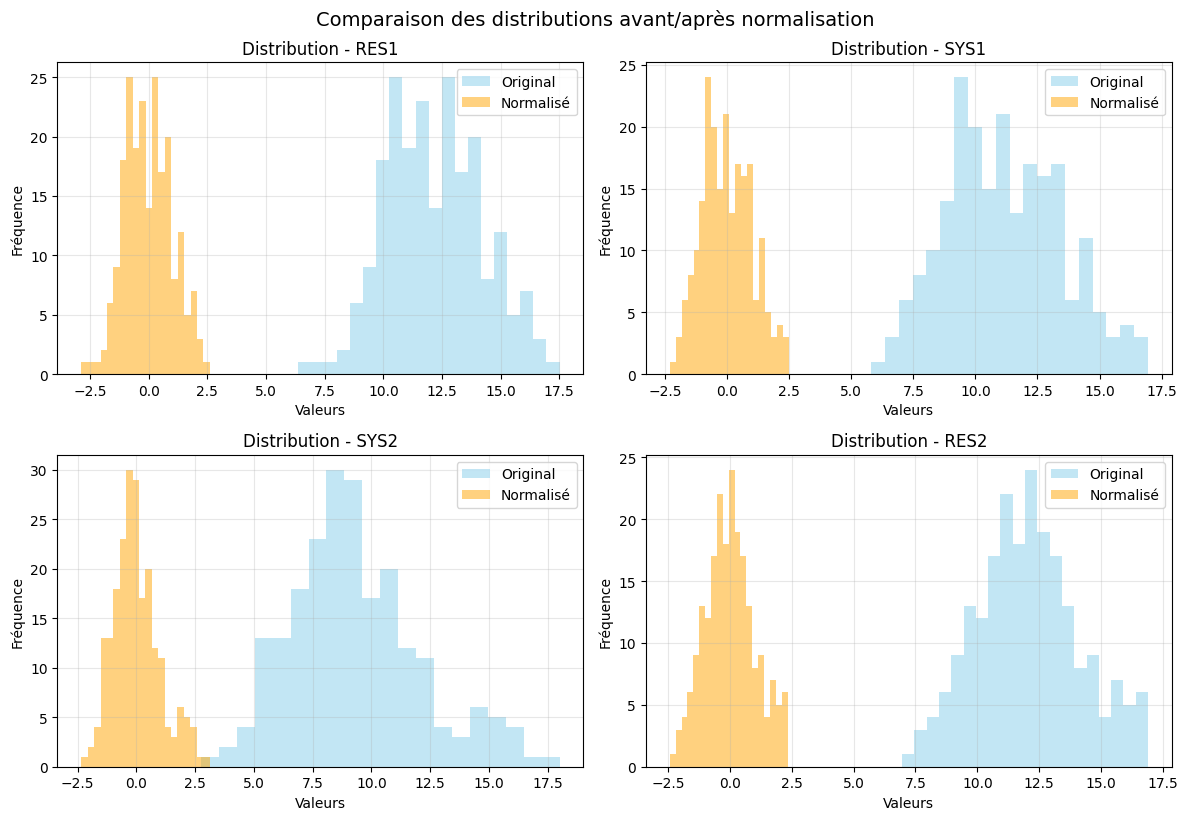

In [ ]:
# Normalisation des notes avec z-score (standardisation) - PROMOTION 2022
print("🔧 NORMALISATION DES NOTES (Z-SCORE) - PROMOTION 2022:")
print("=" * 60)

# Créer une copie pour la normalisation
df_normalized = df.copy()

# Normaliser uniquement les modules disponibles
modules_a_normaliser = [col for col in tous_modules if col in df.columns]

if modules_a_normaliser:
    # Appliquer la normalisation z-score spécifiquement sur la promotion 2022
    scaler = StandardScaler()
    df_normalized[modules_a_normaliser] = scaler.fit_transform(df[modules_a_normaliser])
    
    print(f"✅ Normalisation appliquée sur {len(modules_a_normaliser)} modules")
    print(f"📊 Modules normalisés: {', '.join(modules_a_normaliser)}")
    print(f"🎓 Population: {len(df)} étudiants de la promotion 2022")
    
    # Vérification de la normalisation
    print("\n📈 Statistiques après normalisation (Promotion 2022):")
    stats_norm = df_normalized[modules_a_normaliser].describe().round(3)
    print(stats_norm)
    
    # Visualisation avant/après normalisation pour quelques modules
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    modules_exemple = modules_a_normaliser[:4]  # Prendre les 4 premiers modules
    
    for i, module in enumerate(modules_exemple):
        ax = axes[i//2, i%2]
        
        # Distribution avant normalisation
        ax.hist(df[module], alpha=0.5, label='Original', bins=20, color='skyblue')
        # Distribution après normalisation
        ax.hist(df_normalized[module], alpha=0.5, label='Normalisé', bins=20, color='orange')
        
        ax.set_title(f'Distribution - {module} (Promo 2022)')
        ax.set_xlabel('Valeurs')
        ax.set_ylabel('Fréquence')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Comparaison des distributions avant/après normalisation - Promotion 2022', y=1.02, fontsize=14)
    plt.show()
    
    # Statistiques comparatives pour la promotion 2022
    print(f"\n📊 Résumé de la normalisation (Promotion 2022):")
    print(f"   • Étudiants traités: {len(df)}")
    print(f"   • Modules normalisés: {len(modules_a_normaliser)}")
    print(f"   • Moyenne après normalisation: ~0.000")
    print(f"   • Écart-type après normalisation: ~1.000")
    
else:
    print("❌ Aucun module à normaliser trouvé")

## 4. Calcul des scores par spécialité

In [47]:
def calculer_scores_specialites(df_data, specialites_dict):
    """
    Calcule les scores pour chaque spécialité selon les formules définies.
    
    Formules:
    - Score_SIQ = (RES1 + SYS1 + SYS2 + RES2 + SEC) / 5
    - Score_SID = (ANUM + RO + THP + ARCH) / 4  
    - Score_SIT = (ORG + CPROJ + PROJ + MCSI) / 4
    - Score_SIL = (IGL + BDD) / 2
    """
    scores_df = df_data[['Matricule']].copy()
    
    for specialite, modules in specialites_dict.items():
        # Vérifier quels modules sont disponibles pour cette spécialité
        modules_disponibles = [m for m in modules if m in df_data.columns]
        
        if modules_disponibles:
            # Calculer la moyenne des modules disponibles pour cette spécialité
            scores_df[f'Score_{specialite}'] = df_data[modules_disponibles].mean(axis=1)
            
            print(f"✅ {specialite}: Calculé avec {len(modules_disponibles)}/{len(modules)} modules")
            print(f"   Modules utilisés: {', '.join(modules_disponibles)}")
            if len(modules_disponibles) != len(modules):
                modules_manquants = [m for m in modules if m not in df_data.columns]
                print(f"   ⚠️  Modules manquants: {', '.join(modules_manquants)}")
        else:
            print(f"❌ {specialite}: Aucun module disponible")
            scores_df[f'Score_{specialite}'] = np.nan
    
    return scores_df

# Calcul des scores pour chaque spécialité
print("🎯 CALCUL DES SCORES PAR SPÉCIALITÉ:")
print("=" * 50)

scores_df = calculer_scores_specialites(df_normalized, specialites)

# Afficher les statistiques des scores
colonnes_scores = [col for col in scores_df.columns if col.startswith('Score_')]
if colonnes_scores:
    print(f"\n📊 Statistiques des scores calculés:")
    print(scores_df[colonnes_scores].describe().round(3))
    
    # Afficher quelques exemples
    print(f"\n📋 Exemples de scores pour les premiers étudiants:")
    exemples = scores_df[['Matricule'] + colonnes_scores].head(10)
    print(exemples.round(3))
else:
    print("❌ Aucun score calculé")

🎯 CALCUL DES SCORES PAR SPÉCIALITÉ:
✅ SIQ: Calculé avec 5/5 modules
   Modules utilisés: RES1, SYS1, SYS2, RES2, SEC
✅ SID: Calculé avec 4/4 modules
   Modules utilisés: ANUM, RO, THP, ARCH
✅ SIT: Calculé avec 4/4 modules
   Modules utilisés: ORG, CPROJ, PROJ, MCSI
✅ SIL: Calculé avec 2/2 modules
   Modules utilisés: IGL, BDD

📊 Statistiques des scores calculés:
       Score_SIQ  Score_SID  Score_SIT  Score_SIL
count    217.000    217.000    217.000    217.000
mean      -0.000     -0.000      0.000     -0.000
std        0.820      0.808      0.693      0.871
min       -1.434     -1.750     -2.004     -1.992
25%       -0.599     -0.572     -0.484     -0.565
50%       -0.101     -0.088      0.036      0.007
75%        0.428      0.447      0.493      0.568
max        2.286      2.447      1.767      2.531

📋 Exemples de scores pour les premiers étudiants:
  Matricule  Score_SIQ  Score_SID  Score_SIT  Score_SIL
0   22/0040      2.268      2.447      1.767      2.531
1   22/0030      2.286

## 5. Normalisation des scores de spécialité

In [48]:
def normaliser_scores_profil(scores_df):
    """
    Normalise les scores de spécialité pour chaque étudiant afin qu'ils somment à 1.
    Cela crée un 'profil de compatibilité' pour chaque étudiant.
    """
    # Copier les données
    profils_df = scores_df.copy()
    
    # Identifier les colonnes de scores
    colonnes_scores = [col for col in scores_df.columns if col.startswith('Score_')]
    
    if colonnes_scores:
        # Pour chaque étudiant, normaliser les scores pour qu'ils somment à 1
        scores_array = scores_df[colonnes_scores].values
        
        # Éviter la division par zéro en ajoutant une petite valeur
        sommes = np.sum(scores_array, axis=1, keepdims=True)
        sommes = np.where(sommes == 0, 1e-8, sommes)
        
        # Normalisation
        scores_normalises = scores_array / sommes
        
        # Remplacer les colonnes de scores par les scores normalisés
        for i, col in enumerate(colonnes_scores):
            profils_df[col.replace('Score_', 'Profil_')] = scores_normalises[:, i]
        
        print("✅ Normalisation des scores terminée - Les profils somment maintenant à 1")
        
        # Vérification que les profils somment bien à 1
        colonnes_profils = [col for col in profils_df.columns if col.startswith('Profil_')]
        sommes_verification = profils_df[colonnes_profils].sum(axis=1)
        print(f"📊 Vérification - Somme des profils: min={sommes_verification.min():.3f}, max={sommes_verification.max():.3f}")
        
        return profils_df
    else:
        print("❌ Aucune colonne de score trouvée")
        return scores_df

# Normalisation des scores pour créer les profils de compatibilité
print("⚖️  NORMALISATION DES SCORES (PROFILS DE COMPATIBILITÉ):")
print("=" * 60)

profils_df = normaliser_scores_profil(scores_df)

# Afficher les profils pour quelques étudiants
colonnes_profils = [col for col in profils_df.columns if col.startswith('Profil_')]
if colonnes_profils:
    print(f"\n📋 Exemples de profils de compatibilité:")
    exemples_profils = profils_df[['Matricule'] + colonnes_profils].head(10)
    print(exemples_profils.round(3))
    
    # Statistiques des profils
    print(f"\n📊 Statistiques des profils:")
    print(profils_df[colonnes_profils].describe().round(3))

⚖️  NORMALISATION DES SCORES (PROFILS DE COMPATIBILITÉ):
✅ Normalisation des scores terminée - Les profils somment maintenant à 1
📊 Vérification - Somme des profils: min=1.000, max=1.000

📋 Exemples de profils de compatibilité:
  Matricule  Profil_SIQ  Profil_SID  Profil_SIT  Profil_SIL
0   22/0040       0.252       0.272       0.196       0.281
1   22/0030       0.307       0.300       0.121       0.271
2   22/0051       0.265       0.359       0.121       0.255
3   22/0236       0.277       0.280       0.219       0.223
4   22/0174       0.325       0.388       0.030       0.257
5   22/0196       0.318       0.284       0.136       0.263
6   22/0145       0.253       0.258       0.230       0.259
7   21/0215       0.301       0.344       0.089       0.266
8   22/0214       0.326       0.172       0.300       0.202
9   22/0061       0.329       0.213       0.148       0.309

📊 Statistiques des profils:
       Profil_SIQ  Profil_SID  Profil_SIT  Profil_SIL
count     217.000     217.000

## 6. Génération des recommandations

In [49]:
def generer_recommandations(df_data, profils_df, specialites_dict):
    """
    Génère les recommandations de spécialité avec explications pour chaque étudiant.
    """
    recommandations = []
    
    # Colonnes des scores originaux et des profils
    colonnes_scores = [col for col in profils_df.columns if col.startswith('Score_')]
    colonnes_profils = [col for col in profils_df.columns if col.startswith('Profil_')]
    
    for index, row in profils_df.iterrows():
        matricule = row['Matricule']
        
        # Trouver la spécialité recommandée (score le plus élevé)
        scores_etudiant = {col.replace('Score_', ''): row[col] for col in colonnes_scores if not pd.isna(row[col])}
        profil_etudiant = {col.replace('Profil_', ''): row[col] for col in colonnes_profils if not pd.isna(row[col])}
        
        if scores_etudiant:
            # Spécialité recommandée
            specialite_recommandee = max(scores_etudiant.keys(), key=lambda x: scores_etudiant[x])
            score_max = scores_etudiant[specialite_recommandee]
            
            # Trouver les modules les plus forts pour l'explication
            modules_specialite = specialites_dict[specialite_recommandee]
            modules_disponibles = [m for m in modules_specialite if m in df_data.columns]
            
            if modules_disponibles:
                # Récupérer les notes de l'étudiant pour ces modules
                etudiant_data = df_data[df_data['Matricule'] == matricule]
                if not etudiant_data.empty:
                    notes_modules = {m: etudiant_data[m].iloc[0] for m in modules_disponibles}
                    # Trouver les 2 modules les plus forts
                    modules_forts = sorted(notes_modules.items(), key=lambda x: x[1], reverse=True)[:2]
                    modules_forts_noms = [m[0] for m in modules_forts]
                    
                    # Générer l'explication
                    explication = f"Les modules les plus forts de l'étudiant sont {', '.join(modules_forts_noms)}, qui correspondent bien à la spécialité {specialite_recommandee}."
                else:
                    explication = f"Recommandation basée sur les scores calculés pour {specialite_recommandee}."
            else:
                explication = f"Recommandation basée sur les scores disponibles pour {specialite_recommandee}."
            
            # Créer l'entrée de recommandation
            recommandation = {
                'Matricule': matricule,
                'Spécialité_Recommandée': specialite_recommandee,
                'Score_Principal': round(score_max, 3),
                'Profil_Complet': {k: round(v, 3) for k, v in profil_etudiant.items()},
                'Explication': explication
            }
            
            # Ajouter les scores individuels
            for spec, score in scores_etudiant.items():
                recommandation[f'Score_{spec}'] = round(score, 3)
            
            recommandations.append(recommandation)
    
    return pd.DataFrame(recommandations)

# Génération des recommandations
print("🎯 GÉNÉRATION DES RECOMMANDATIONS:")
print("=" * 50)

recommandations_df = generer_recommandations(df_normalized, profils_df, specialites)

if not recommandations_df.empty:
    print(f"✅ Recommandations générées pour {len(recommandations_df)} étudiants")
    
    # Distribution des recommandations
    print(f"\n📊 Distribution des recommandations:")
    distribution = recommandations_df['Spécialité_Recommandée'].value_counts()
    for spec, count in distribution.items():
        pourcentage = (count / len(recommandations_df)) * 100
        print(f"  {spec}: {count} étudiants ({pourcentage:.1f}%)")
    
    # Afficher quelques exemples de recommandations
    print(f"\n📋 Exemples de recommandations:")
    for i in range(min(5, len(recommandations_df))):
        row = recommandations_df.iloc[i]
        print(f"\n👤 Étudiant {row['Matricule']}:")
        print(f"   🎯 Recommandation: {row['Spécialité_Recommandée']} (Score: {row['Score_Principal']})")
        print(f"   📊 Profil: {row['Profil_Complet']}")
        print(f"   💡 Explication: {row['Explication']}")
else:
    print("❌ Aucune recommandation générée")

🎯 GÉNÉRATION DES RECOMMANDATIONS:
✅ Recommandations générées pour 217 étudiants

📊 Distribution des recommandations:
  SIT: 77 étudiants (35.5%)
  SIL: 56 étudiants (25.8%)
  SIQ: 47 étudiants (21.7%)
  SID: 37 étudiants (17.1%)

📋 Exemples de recommandations:

👤 Étudiant 22/0040:
   🎯 Recommandation: SIL (Score: 2.531)
   📊 Profil: {'SIQ': 0.252, 'SID': 0.272, 'SIT': 0.196, 'SIL': 0.281}
   💡 Explication: Les modules les plus forts de l'étudiant sont BDD, IGL, qui correspondent bien à la spécialité SIL.

👤 Étudiant 22/0030:
   🎯 Recommandation: SIQ (Score: 2.286)
   📊 Profil: {'SIQ': 0.307, 'SID': 0.3, 'SIT': 0.121, 'SIL': 0.271}
   💡 Explication: Les modules les plus forts de l'étudiant sont SEC, SYS2, qui correspondent bien à la spécialité SIQ.

👤 Étudiant 22/0051:
   🎯 Recommandation: SID (Score: 2.391)
   📊 Profil: {'SIQ': 0.265, 'SID': 0.359, 'SIT': 0.121, 'SIL': 0.255}
   💡 Explication: Les modules les plus forts de l'étudiant sont RO, ANUM, qui correspondent bien à la spécialit

## 7. Analyse et visualisation des résultats

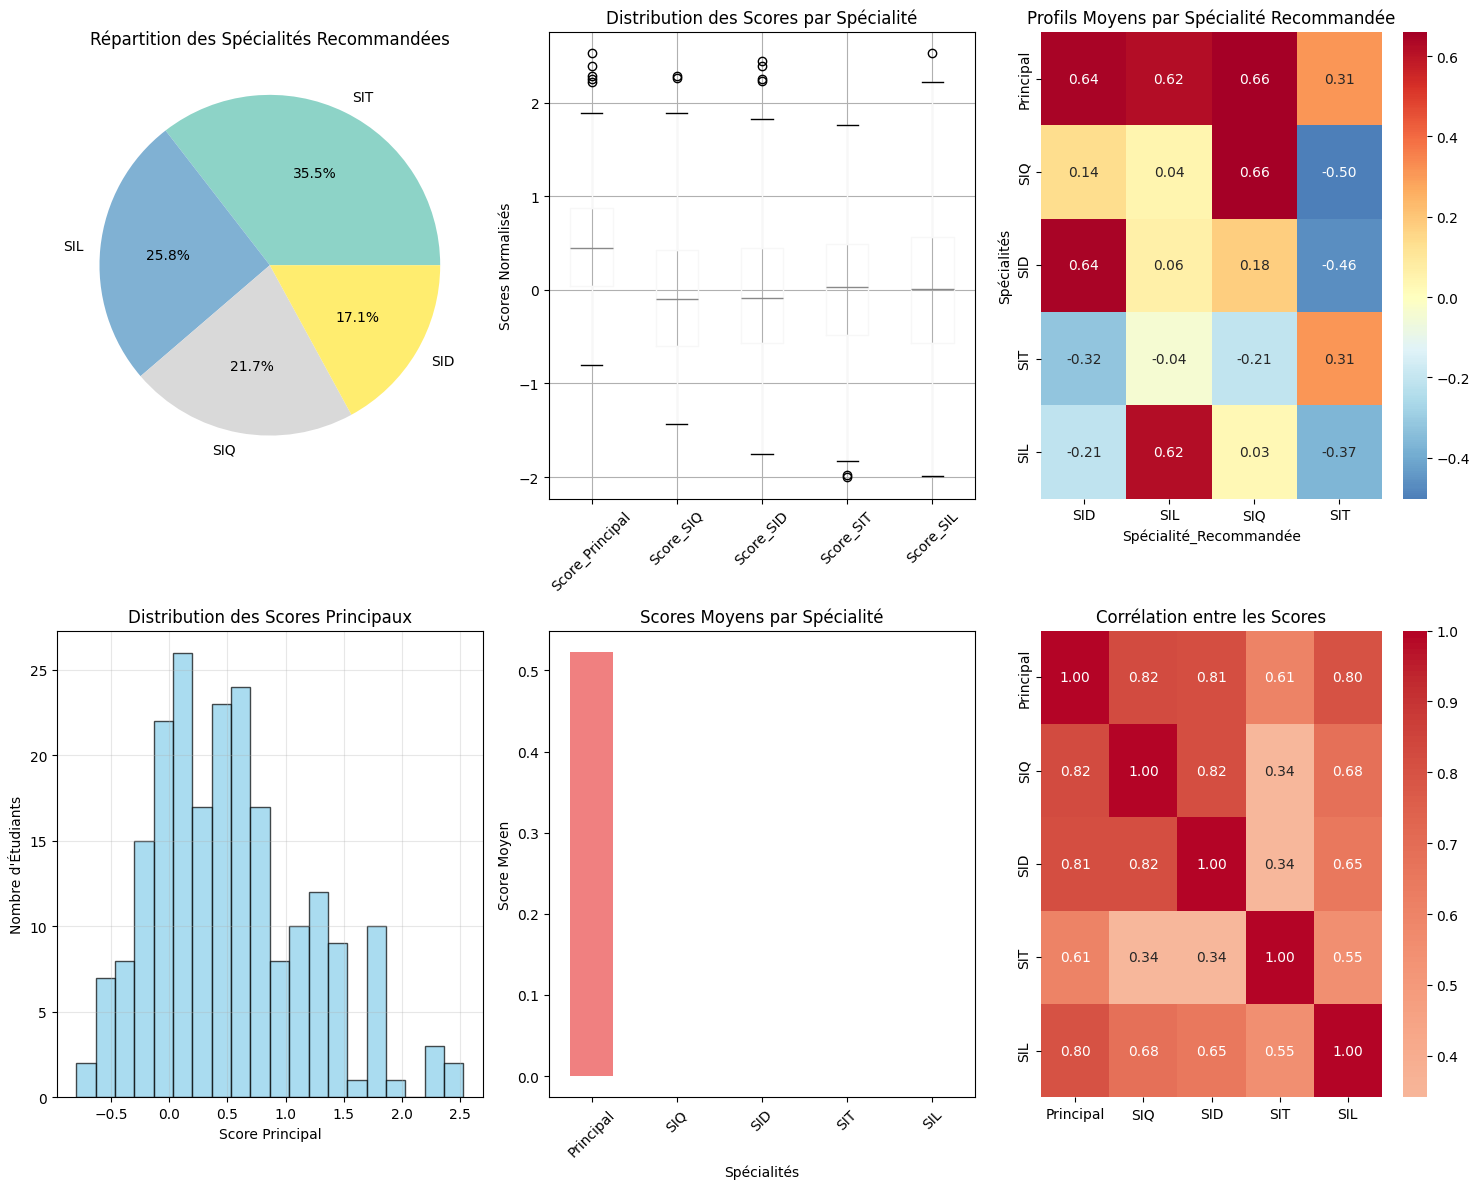

📈 ANALYSE STATISTIQUE DÉTAILLÉE:

🎯 Statistiques par spécialité recommandée:

SIT (77 étudiants):
  Score principal moyen: 0.312
  Score principal médian: 0.281
  Écart-type: 0.504

SIL (56 étudiants):
  Score principal moyen: 0.618
  Score principal médian: 0.578
  Écart-type: 0.627

SIQ (47 étudiants):
  Score principal moyen: 0.660
  Score principal médian: 0.548
  Écart-type: 0.777

SID (37 étudiants):
  Score principal moyen: 0.643
  Score principal médian: 0.449
  Écart-type: 0.784


In [50]:
# Visualisation des résultats
if not recommandations_df.empty:
    
    # 1. Distribution des recommandations
    plt.figure(figsize=(15, 12))
    
    # Graphique 1: Répartition des spécialités recommandées
    plt.subplot(2, 3, 1)
    distribution = recommandations_df['Spécialité_Recommandée'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(distribution)))
    plt.pie(distribution.values, labels=distribution.index, autopct='%1.1f%%', colors=colors)
    plt.title('Répartition des Spécialités Recommandées')
    
    # Graphique 2: Distribution des scores par spécialité
    plt.subplot(2, 3, 2)
    colonnes_scores_spec = [col for col in recommandations_df.columns if col.startswith('Score_')]
    if colonnes_scores_spec:
        scores_data = recommandations_df[colonnes_scores_spec]
        scores_data.boxplot(ax=plt.gca())
        plt.title('Distribution des Scores par Spécialité')
        plt.xticks(rotation=45)
        plt.ylabel('Scores Normalisés')
    
    # Graphique 3: Heatmap des profils moyens par spécialité recommandée
    plt.subplot(2, 3, 3)
    if colonnes_scores_spec:
        profils_moyens = recommandations_df.groupby('Spécialité_Recommandée')[colonnes_scores_spec].mean()
        profils_moyens.columns = [col.replace('Score_', '') for col in profils_moyens.columns]
        sns.heatmap(profils_moyens.T, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f')
        plt.title('Profils Moyens par Spécialité Recommandée')
        plt.ylabel('Spécialités')
    
    # Graphique 4: Histogramme des scores principaux
    plt.subplot(2, 3, 4)
    plt.hist(recommandations_df['Score_Principal'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribution des Scores Principaux')
    plt.xlabel('Score Principal')
    plt.ylabel('Nombre d\'Étudiants')
    plt.grid(True, alpha=0.3)
    
    # Graphique 5: Comparaison des scores moyens par spécialité
    plt.subplot(2, 3, 5)
    if colonnes_scores_spec:
        scores_moyens = recommandations_df[colonnes_scores_spec].mean()
        scores_moyens.index = [col.replace('Score_', '') for col in scores_moyens.index]
        scores_moyens.plot(kind='bar', color='lightcoral')
        plt.title('Scores Moyens par Spécialité')
        plt.xlabel('Spécialités')
        plt.ylabel('Score Moyen')
        plt.xticks(rotation=45)
    
    # Graphique 6: Matrice de corrélation des scores
    plt.subplot(2, 3, 6)
    if len(colonnes_scores_spec) > 1:
        correlation_matrix = recommandations_df[colonnes_scores_spec].corr()
        correlation_matrix.index = [col.replace('Score_', '') for col in correlation_matrix.index]
        correlation_matrix.columns = [col.replace('Score_', '') for col in correlation_matrix.columns]
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Corrélation entre les Scores')
    
    plt.tight_layout()
    plt.show()
    
    # Analyse statistique supplémentaire
    print("📈 ANALYSE STATISTIQUE DÉTAILLÉE:")
    print("=" * 50)
    
    # Statistiques par spécialité recommandée
    print("\n🎯 Statistiques par spécialité recommandée:")
    for specialite in distribution.index:
        subset = recommandations_df[recommandations_df['Spécialité_Recommandée'] == specialite]
        print(f"\n{specialite} ({len(subset)} étudiants):")
        print(f"  Score principal moyen: {subset['Score_Principal'].mean():.3f}")
        print(f"  Score principal médian: {subset['Score_Principal'].median():.3f}")
        print(f"  Écart-type: {subset['Score_Principal'].std():.3f}")

else:
    print("❌ Pas de données à visualiser")

## 8. Fonction de recommandation complète

In [ ]:
class SystemeRecommandationSpecialites:
    """
    Système de recommandation complet pour assigner les étudiants aux spécialités.
    """
    
    def __init__(self):
        self.specialites = {
            'SIQ': ['RES1', 'SYS1', 'SYS2', 'RES2', 'SEC'],
            'SID': ['ANUM', 'RO', 'THP', 'ARCH'],
            'SIT': ['ORG', 'CPROJ', 'PROJ', 'MCSI'],
            'SIL': ['IGL', 'BDD']
        }
        self.scaler = None
        self.modules_disponibles = []
        self.df_original = None  # Stocker les données originales
    
    def entrainer(self, df_data):
        """
        Entraîne le système sur un jeu de données pour la normalisation.
        """
        # Sauvegarder les données originales
        self.df_original = df_data.copy()
        
        # Identifier les modules disponibles
        tous_modules = []
        for modules in self.specialites.values():
            tous_modules.extend(modules)
        
        self.modules_disponibles = [m for m in tous_modules if m in df_data.columns]
        
        if self.modules_disponibles:
            # Initialiser et entraîner le scaler
            self.scaler = StandardScaler()
            self.scaler.fit(df_data[self.modules_disponibles])
            print(f"✅ Système entraîné sur {len(self.modules_disponibles)} modules")
        else:
            print("❌ Aucun module requis trouvé dans les données")
    
    def recommander_par_matricule(self, matricule):
        """
        Recommande une spécialité pour un étudiant en utilisant son matricule.
        
        Args:
            matricule (str): Le matricule de l'étudiant
        
        Returns:
            dict: Recommandation complète avec profil et explication
        """
        if self.df_original is None:
            return {"erreur": "Le système doit être entraîné avant d'être utilisé"}
        
        # Trouver l'étudiant dans les données
        etudiant_row = self.df_original[self.df_original['Matricule'] == matricule]
        
        if etudiant_row.empty:
            return {"erreur": f"Étudiant avec matricule {matricule} non trouvé"}
        
        # Extraire les notes de l'étudiant
        etudiant = etudiant_row.iloc[0]
        notes_etudiant = {col: etudiant[col] for col in self.modules_disponibles 
                         if col in etudiant and not pd.isna(etudiant[col])}
        
        if len(notes_etudiant) != len(self.modules_disponibles):
            modules_manquants = [m for m in self.modules_disponibles if m not in notes_etudiant]
            return {"erreur": f"Modules manquants pour cet étudiant: {modules_manquants}"}
        
        return self.recommander_etudiant(notes_etudiant)
    
    def recommander_etudiant(self, notes_etudiant):
        """
        Recommande une spécialité pour un étudiant donné.
        
        Args:
            notes_etudiant (dict): Dictionnaire {module: note} pour l'étudiant
        
        Returns:
            dict: Recommandation complète avec profil et explication
        """
        if self.scaler is None:
            return {"erreur": "Le système doit être entraîné avant d'être utilisé"}
        
        # Créer un DataFrame pour l'étudiant
        etudiant_df = pd.DataFrame([notes_etudiant])
        
        # Vérifier les modules manquants
        modules_manquants = [m for m in self.modules_disponibles if m not in etudiant_df.columns]
        if modules_manquants:
            return {"erreur": f"Modules manquants: {modules_manquants}"}
        
        # Normaliser les notes
        notes_normalisees = self.scaler.transform(etudiant_df[self.modules_disponibles])[0]
        notes_norm_dict = dict(zip(self.modules_disponibles, notes_normalisees))
        
        # Calculer les scores par spécialité
        scores = {}
        for spec, modules in self.specialites.items():
            modules_spec = [m for m in modules if m in self.modules_disponibles]
            if modules_spec:
                scores[spec] = np.mean([notes_norm_dict[m] for m in modules_spec])
        
        if not scores:
            return {"erreur": "Impossible de calculer les scores"}
        
        # *** CORRECTION: Utiliser softmax pour éviter les valeurs négatives ***
        # Appliquer softmax pour transformer les scores en probabilités positives
        scores_array = np.array(list(scores.values()))
        # Ajouter une constante pour éviter les problèmes d'overflow
        scores_array_shifted = scores_array - np.max(scores_array)
        exp_scores = np.exp(scores_array_shifted)
        profil_values = exp_scores / np.sum(exp_scores)
        
        # Créer le profil final
        profil = dict(zip(scores.keys(), profil_values))
        
        # Trouver la spécialité recommandée
        specialite_recommandee = max(scores.keys(), key=lambda x: scores[x])
        
        # Trouver les modules les plus forts pour l'explication
        modules_specialite = [m for m in self.specialites[specialite_recommandee] if m in notes_etudiant]
        if modules_specialite:
            notes_modules = {m: notes_etudiant[m] for m in modules_specialite}
            modules_forts = sorted(notes_modules.items(), key=lambda x: x[1], reverse=True)[:2]
            modules_forts_noms = [m[0] for m in modules_forts]
            
            explication = f"Les modules les plus forts de l'étudiant sont {', '.join(modules_forts_noms)} (notes: {', '.join([f'{m[1]:.1f}' for m in modules_forts])}), qui correspondent bien à la spécialité {specialite_recommandee}."
        else:
            explication = f"Recommandation basée sur l'analyse des scores pour {specialite_recommandee}."
        
        return {
            "matricule": notes_etudiant.get('Matricule', 'N/A'),
            "specialite_recommandee": specialite_recommandee,
            "scores_bruts": {k: round(v, 3) for k, v in scores.items()},
            "profil": {k: round(v, 3) for k, v in profil.items()},
            "explication": explication,
            "confiance": round(max(profil.values()), 3)
        }
    
    def recommander_batch(self, df_data):
        """
        Recommande des spécialités pour un lot d'étudiants.
        """
        if self.scaler is None:
            print("❌ Le système doit être entraîné avant d'être utilisé")
            return pd.DataFrame()
        
        recommandations = []
        
        for index, row in df_data.iterrows():
            if 'Matricule' in row:
                matricule = row['Matricule']
                notes = {col: row[col] for col in self.modules_disponibles if col in row and not pd.isna(row[col])}
                
                if len(notes) == len(self.modules_disponibles):
                    reco = self.recommander_etudiant(notes)
                    if "erreur" not in reco:
                        reco['Matricule'] = matricule
                        recommandations.append(reco)
        
        return pd.DataFrame(recommandations)

# Initialisation et test du système
print("🤖 SYSTÈME DE RECOMMANDATION COMPLET:")
print("=" * 60)

# Créer et entraîner le système
systeme = SystemeRecommandationSpecialites()
systeme.entrainer(df)

# Test sur un étudiant exemple
if not df.empty and len(systeme.modules_disponibles) > 0:
    print(f"\n🧪 Test sur un étudiant exemple:")
    
    # Prendre le premier étudiant comme exemple
    premier_etudiant = df.iloc[0]
    matricule_test = premier_etudiant['Matricule']
    
    print(f"👤 Test avec matricule: {matricule_test}")
    
    # Test de la nouvelle fonction recommander_par_matricule
    recommandation = systeme.recommander_par_matricule(matricule_test)
    
    if "erreur" not in recommandation:
        print(f"\n🎯 Résultat de la recommandation:")
        print(f"   Spécialité recommandée: {recommandation['specialite_recommandee']}")
        print(f"   Niveau de confiance: {recommandation['confiance']:.1%}")
        print(f"   Scores bruts: {recommandation['scores_bruts']}")
        print(f"   Profil de compatibilité:")
        for spec, score in recommandation['profil'].items():
            print(f"      {spec}: {score:.1%}")
        print(f"   Explication: {recommandation['explication']}")
    else:
        print(f"❌ Erreur: {recommandation['erreur']}")
else:
    print("❌ Impossible de tester - données insuffisantes")

🤖 SYSTÈME DE RECOMMANDATION COMPLET (VERSION CORRIGÉE):
✅ Système entraîné sur 15 modules

🧪 Test sur un étudiant exemple:
👤 Test avec matricule: 22/0040

🎯 Résultat de la recommandation:
   Spécialité recommandée: SIL
   Niveau de confiance: 31.7%
   Scores bruts: {'SIQ': np.float64(2.268), 'SID': np.float64(2.447), 'SIT': np.float64(1.767), 'SIL': np.float64(2.531)}
   Profil de compatibilité:
      SIQ: 24.4%
      SID: 29.2%
      SIT: 14.8%
      SIL: 31.7%
   Explication: Les modules les plus forts de l'étudiant sont BDD, IGL (notes: 17.6, 16.1), qui correspondent bien à la spécialité SIL.


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exemple : dictionnaire des spécialités
specialites = {
    'SIQ': ['RES1', 'SYS1', 'SYS2', 'RES2', 'SEC'],
    'SID': ['ANUM', 'RO', 'THP', 'ARCH'],
    'SIT': ['ORG', 'CPROJ', 'PROJ', 'MCSI'],
    'SIL': ['IGL', 'BDD']
}

# Fonction utilitaire
def analyser_etudiant(matricule):
    """
    Fonction pratique pour analyser un étudiant par son matricule.
    Affiche les résultats de manière formatée.
    """
    print(f"🔍 ANALYSE DE L'ÉTUDIANT {matricule}:")
    print("=" * 50)
    
    # Récupérer les données de l'étudiant
    etudiant_data = df[df['Matricule'] == matricule]
    if etudiant_data.empty:
        print(f"❌ Étudiant {matricule} non trouvé dans les données")
        return None
    
    etudiant_row = etudiant_data.iloc[0]
    
    # Afficher les notes de l'étudiant dans un tableau (UNE SEULE LIGNE)
    print(f"📚 NOTES DE L'ÉTUDIANT:")
    print("-" * 50)
    
    # Liste des modules à afficher
    modules_notes = ['SYS1', 'RES1', 'SYS2', 'RES2', 'SEC', 
                     'ANUM', 'RO', 'THP', 'ARCH', 
                     'ORG', 'CPROJ', 'PROJ', 'MCSI', 
                     'IGL', 'BDD']
    
    # Construire un dictionnaire {Module: Note}
    notes_dict = {}
    for module in modules_notes:
        if module in etudiant_row and not pd.isna(etudiant_row[module]):
            notes_dict[module] = f"{etudiant_row[module]:.2f}"
        else:
            notes_dict[module] = "-"
    
    # Transformer en DataFrame avec une seule ligne
    notes_df = pd.DataFrame([notes_dict])
    print(notes_df.to_string(index=False))
    
    # Analyser avec le système de recommandation
    recommandation = systeme.recommander_par_matricule(matricule)
    
    if "erreur" in recommandation:
        print(f"❌ Erreur: {recommandation['erreur']}")
        return None
    
    # Affichage formaté des résultats
    print(f"\n🎯 RECOMMANDATION:")
    print("-" * 30)
    print(f"👤 Matricule: {matricule}")
    print(f"🎯 Spécialité Recommandée: {recommandation['specialite_recommandee']}")
    print(f"📊 Niveau de Confiance: {recommandation['confiance']:.1%}")
    
    print(f"\n📈 Profil de Compatibilité:")
    profil_trie = sorted(recommandation['profil'].items(), key=lambda x: x[1], reverse=True)
    for i, (spec, score) in enumerate(profil_trie):
        emoji = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else "📍"
        print(f"   {emoji} {spec}: {score:.1%}")
    
    print(f"\n💡 Explication: {recommandation['explication']}")
    
    # Visualisation du profil
    plt.figure(figsize=(12, 8))
    
    # Graphique en barres
    plt.subplot(2, 2, 1)
    specs = list(recommandation['profil'].keys())
    scores = list(recommandation['profil'].values())
    colors = ['gold' if spec == recommandation['specialite_recommandee'] else 'lightblue' for spec in specs]
    
    bars = plt.bar(specs, scores, color=colors, alpha=0.7, edgecolor='black')
    plt.title(f'Profil de Compatibilité - {matricule}')
    plt.ylabel('Score de Compatibilité')
    plt.xticks(rotation=45)
    
    # Ajouter les valeurs sur les barres
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.1%}', ha='center', va='bottom')
    
    # Graphique en secteurs
    plt.subplot(2, 2, 2)
    plt.pie(scores, labels=specs, autopct='%1.1f%%', startangle=90)
    plt.title(f'Répartition des Compatibilités')
    
    # Graphique des notes par spécialité (moyennes)
    plt.subplot(2, 2, 3)
    moyennes = {}
    for spec, modules in specialites.items():
        modules_dispo = [m for m in modules if m in etudiant_row and not pd.isna(etudiant_row[m])]
        if modules_dispo:
            moyenne = np.mean([etudiant_row[m] for m in modules_dispo])
            moyennes[spec] = moyenne
    
    if moyennes:
        spec_noms = list(moyennes.keys())
        spec_moyennes = list(moyennes.values())
        colors_moyennes = ['gold' if spec == recommandation['specialite_recommandee'] else 'lightcoral' for spec in spec_noms]
        
        bars = plt.bar(spec_noms, spec_moyennes, color=colors_moyennes, alpha=0.7, edgecolor='black')
        plt.title('Moyennes (sans normalisation) par Spécialité')
        plt.ylabel('Moyenne des Notes')
        plt.xticks(rotation=45)
        
        # Ajouter les valeurs sur les barres
        for bar, moyenne in zip(bars, spec_moyennes):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{moyenne:.1f}', ha='center', va='bottom')
    
    # Comparaison scores normalisés vs moyennes brutes
    plt.subplot(2, 2, 4)
    if moyennes:
        x = np.arange(len(specs))
        width = 0.35
        
        # Scores de compatibilité normalisés
        scores_normalises = [recommandation['profil'][spec] for spec in specs]
        
        # Moyennes brutes (normalisées pour l'affichage)
        moyennes_pour_affichage = []
        for spec in specs:
            if spec in moyennes:
                moyennes_pour_affichage.append(moyennes[spec] / 20)  # Normaliser sur 20
            else:
                moyennes_pour_affichage.append(0)
        
        plt.bar(x - width/2, scores_normalises, width, label='Compatibilité', alpha=0.7)
        plt.bar(x + width/2, moyennes_pour_affichage, width, label='Moyennes (/20)', alpha=0.7)
        
        plt.title('Comparaison Compatibilité vs Moyennes (sans normalisation)')
        plt.xlabel('Spécialités')
        plt.ylabel('Scores')
        plt.xticks(x, specs, rotation=45)
        plt.legend()
    
    plt.tight_layout()
    plt.show()


🔍 ANALYSE DE L'ÉTUDIANT 22/0034:
📚 NOTES DE L'ÉTUDIANT:
--------------------------------------------------
 SYS1  RES1  SYS2  RES2   SEC  ANUM    RO   THP  ARCH   ORG CPROJ  PROJ  MCSI   IGL   BDD
16.80 16.12 15.31 13.49 17.66 15.13 11.70 13.75 15.71 14.41 12.05 13.35 13.12 13.61 13.65

🎯 RECOMMANDATION:
------------------------------
👤 Matricule: 22/0034
🎯 Spécialité Recommandée: SIQ
📊 Niveau de Confiance: 45.2%

📈 Profil de Compatibilité:
   🥇 SIQ: 45.2%
   🥈 SID: 33.3%
   🥉 SIL: 14.7%
   📍 SIT: 6.7%

💡 Explication: Les modules les plus forts de l'étudiant sont SEC, SYS1 (notes: 17.7, 16.8), qui correspondent bien à la spécialité SIQ.


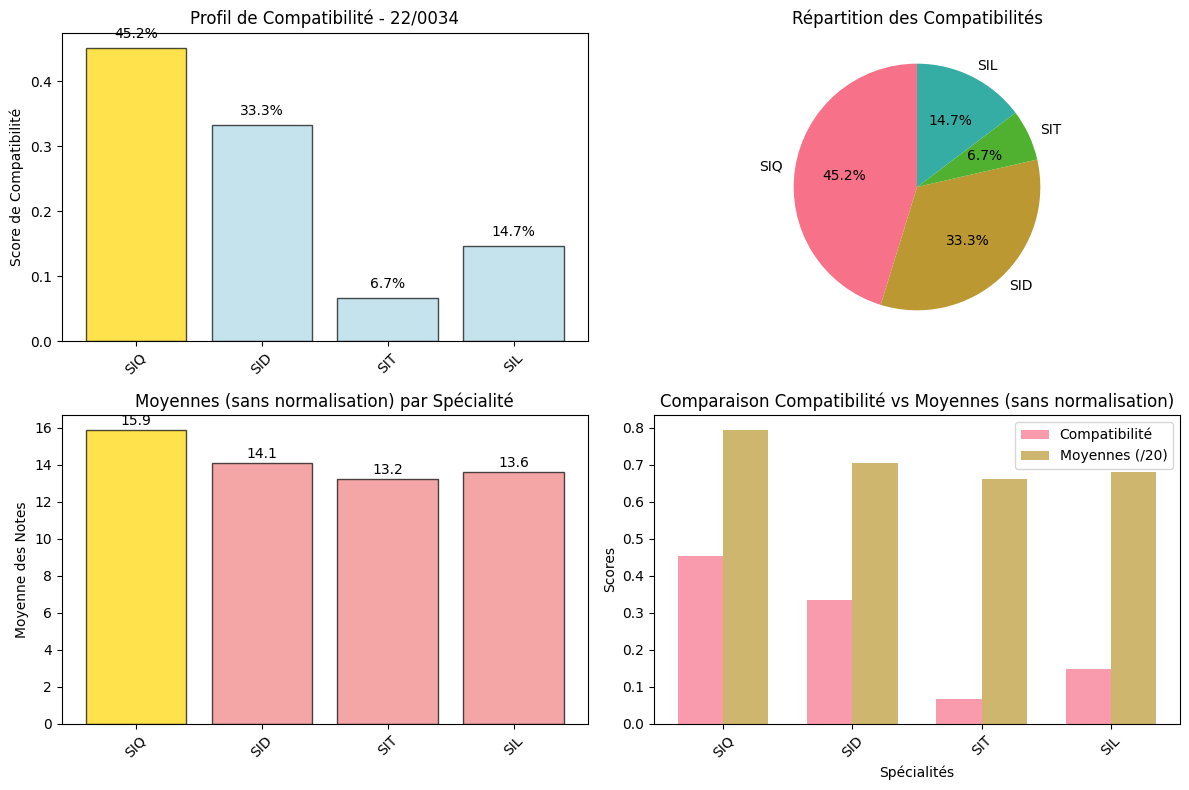

In [58]:
analyser_etudiant('22/0034')

🔍 ANALYSE DE L'ÉTUDIANT 21/0213:
📚 NOTES DE L'ÉTUDIANT:
--------------------------------------------------
 SYS1  RES1  SYS2  RES2   SEC  ANUM    RO   THP  ARCH   ORG CPROJ  PROJ  MCSI   IGL   BDD
13.20 12.74 12.57 11.48 11.62 10.52 11.13 13.62 10.14 12.70 10.82 15.35 11.72 10.48 10.18

🎯 RECOMMANDATION:
------------------------------
👤 Matricule: 21/0213
🎯 Spécialité Recommandée: SIQ
📊 Niveau de Confiance: 39.7%

📈 Profil de Compatibilité:
   🥇 SIQ: 39.7%
   🥈 SID: 30.9%
   🥉 SIT: 21.3%
   📍 SIL: 8.0%

💡 Explication: Les modules les plus forts de l'étudiant sont SYS1, RES1 (notes: 13.2, 12.7), qui correspondent bien à la spécialité SIQ.


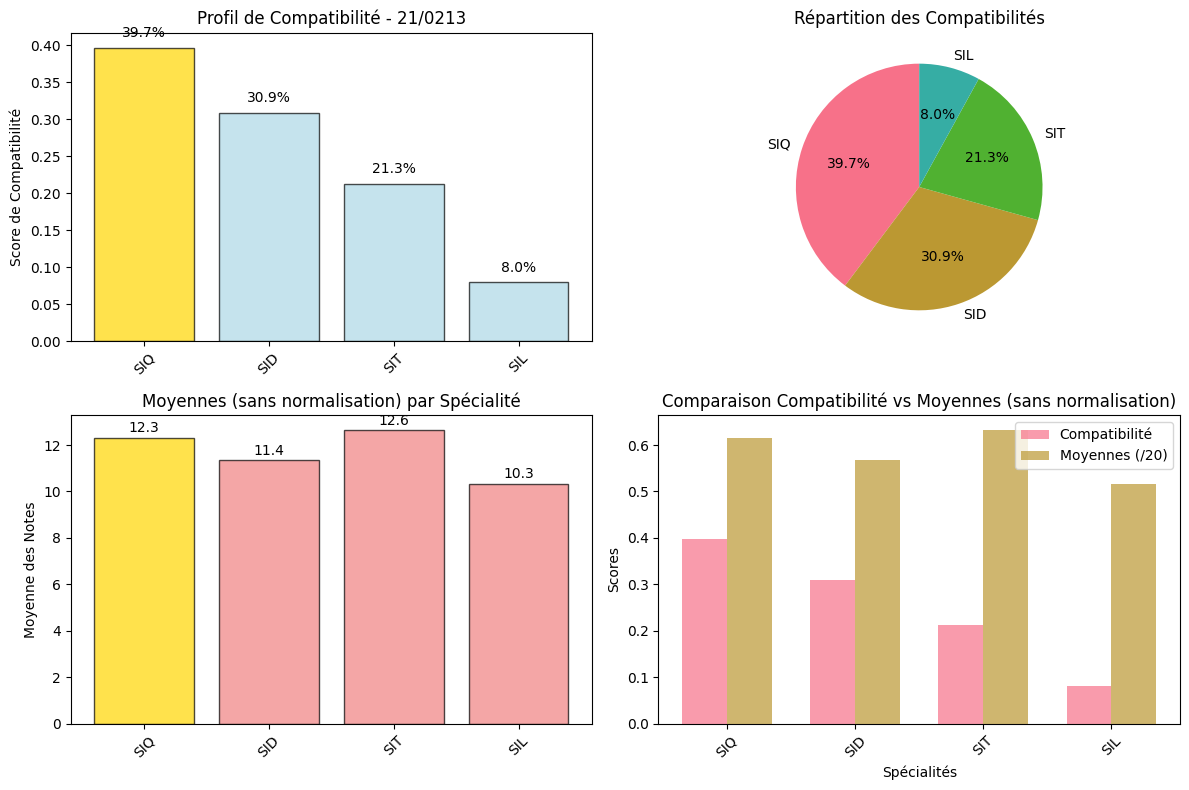

In [59]:
analyser_etudiant('21/0213')

## 9. Conclusion et recommandations

### 📋 Résumé du Système de Recommandation

Ce notebook présente un **système de recommandation complet** pour assigner les étudiants aux spécialités en fonction de leurs performances académiques.

#### 🎯 **Objectifs atteints :**

1. **Normalisation des données** : Application du z-score pour rendre les notes comparables
2. **Calcul des scores de spécialité** : Utilisation des formules définies pour chaque spécialité
3. **Génération de profils de compatibilité** : Normalisation des scores pour créer des profils probabilistes
4. **Recommandations explicatives** : Génération d'explications basées sur les modules les plus forts
5. **Visualisations complètes** : Graphiques pour analyser les résultats et distributions

#### 🔧 **Formules utilisées :**

- **SIQ (Systèmes & Réseaux)** : `(RES1 + SYS1 + SYS2 + RES2 + SEC) / 5`
- **SID (Mathématiques & Algorithmes)** : `(ANUM + RO + THP + ARCH) / 4`
- **SIT (Management & Projets IT)** : `(ORG + CPROJ + PROJ + MCSI) / 4`
- **SIL (Génie Logiciel)** : `(IGL + BDD) / 2`

#### 💡 **Recommandations pour l'amélioration :**

1. **Pondération des modules** : Considérer des poids différents selon l'importance des modules
2. **Facteurs additionnels** : Intégrer les préférences étudiantes, les résultats de stages, etc.
3. **Seuils de confiance** : Établir des seuils minimaux pour les recommandations
4. **Validation croisée** : Comparer avec les affectations réelles pour valider la performance
5. **Interface utilisateur** : Développer une interface web pour faciliter l'utilisation

#### 🚀 **Utilisation pratique :**

Le système peut être utilisé de deux façons :
- **Recommandation individuelle** : `systeme.recommander_etudiant(notes_dict)`
- **Traitement par lots** : `systeme.recommander_batch(dataframe)`

#### 📊 **Métriques de performance à surveiller :**

- Taux d'accord avec les affectations réelles (si disponibles)
- Distribution équilibrée des recommandations
- Cohérence des explications générées
- Stabilité des recommandations face aux variations mineures des notes